In [1]:
# ============================================================
#  OPTION B — Hyperparameter Optimization (Grid Search) + KNN
#  Optimizes : k (1→20), distance metric, weights
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split,cross_val_score,StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

In [2]:
# ── 1. Load & subsample ──────────────────────────────────────
SAMPLE_SIZE = 10_000
RANDOM_SEED = 42
print("Loading dataset …")
data = pd.read_csv("/content/drive/MyDrive/Dataset/A_Z Handwritten Data.csv").astype('float32')
data = data.groupby('0', group_keys=False).apply(lambda g: g.sample(min(len(g), SAMPLE_SIZE // 26), random_state=RANDOM_SEED)).reset_index(drop=True)
X = data.drop('0', axis=1).values
y = data['0'].values.astype(int)
print(f"Working dataset shape: {X.shape}")

Loading dataset …
Working dataset shape: (9984, 784)


/tmp/ipykernel_27430/2932093273.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('0', group_keys=False).apply(lambda g: g.sample(min(len(g), SAMPLE_SIZE // 26), random_state=RANDOM_SEED)).reset_index(drop=True)


In [4]:
# ── 2.Normalise ─────────────────────────────────────────────
scaler  = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# ── 3.Train and test split ────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)

In [6]:
# ── 4. Grid Search over k, metric, weights ───────────────────
# We sweep:
#   k       : 1 → 20
#   metric  : euclidean
#   weights : uniform, distance
k_values  = list(range(1, 21))
metrics   = ['euclidean']
weights   = ['uniform', 'distance']
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
results   = []
best_score = 0
best_params = {}
total_combos = len(k_values) * len(metrics) * len(weights)
print(f"\nGrid Search — {total_combos} combinations × 5-fold CV …\n")
combo_idx = 0
t_gs_start = time.time()
for metric in metrics:
    for w in weights:
        cv_scores_per_k = []
        for k in k_values:
            combo_idx += 1
            knn = KNeighborsClassifier(n_neighbors=k, metric=metric,weights=w,n_jobs=-1)
            scores = cross_val_score(knn, X_train,y_train,cv=cv,scoring='accuracy',n_jobs=-1)
            mean_score = scores.mean()
            cv_scores_per_k.append(mean_score)
            results.append({
                'k': k, 'metric': metric, 'weights': w,
                'cv_mean': mean_score, 'cv_std': scores.std()
            })
            if mean_score > best_score:
                best_score  = mean_score
                best_params = {'k': k, 'metric': metric, 'weights': w}
            print(f"  [{combo_idx:3d}/{total_combos}]  k={k:2d}  "
                  f"metric={metric:11s}  weights={w:8s}  "
                  f"CV acc={mean_score:.4f} ± {scores.std():.4f}")
t_gs = time.time() - t_gs_start
print(f"\nGrid Search finished in {t_gs:.1f}s")
print(f"Best params : {best_params}  (CV acc = {best_score:.4f})")


Grid Search — 40 combinations × 5-fold CV …

  [  1/40]  k= 1  metric=euclidean    weights=uniform   CV acc=0.8475 ± 0.0066
  [  2/40]  k= 2  metric=euclidean    weights=uniform   CV acc=0.8327 ± 0.0043
  [  3/40]  k= 3  metric=euclidean    weights=uniform   CV acc=0.8450 ± 0.0046
  [  4/40]  k= 4  metric=euclidean    weights=uniform   CV acc=0.8456 ± 0.0044
  [  5/40]  k= 5  metric=euclidean    weights=uniform   CV acc=0.8474 ± 0.0060
  [  6/40]  k= 6  metric=euclidean    weights=uniform   CV acc=0.8455 ± 0.0058
  [  7/40]  k= 7  metric=euclidean    weights=uniform   CV acc=0.8406 ± 0.0071
  [  8/40]  k= 8  metric=euclidean    weights=uniform   CV acc=0.8392 ± 0.0062
  [  9/40]  k= 9  metric=euclidean    weights=uniform   CV acc=0.8349 ± 0.0090
  [ 10/40]  k=10  metric=euclidean    weights=uniform   CV acc=0.8315 ± 0.0070
  [ 11/40]  k=11  metric=euclidean    weights=uniform   CV acc=0.8288 ± 0.0064
  [ 12/40]  k=12  metric=euclidean    weights=uniform   CV acc=0.8286 ± 0.0065
  [ 13

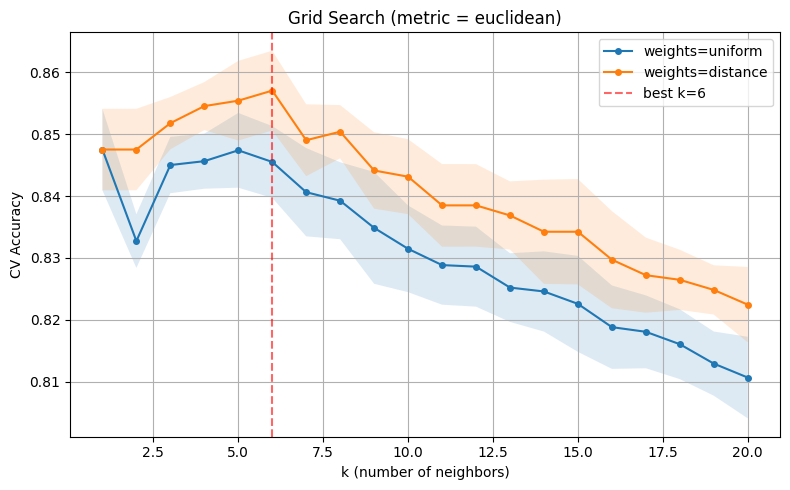

Best k = 6, CV accuracy = 0.8570


In [9]:
# ── 5. Plot CV accuracy for each config ─────────────────
import os
results_df = pd.DataFrame(results)
plt.figure(figsize=(8,5))
metric = metrics[0]
for w in weights:
    subset = results_df[
        (results_df.metric == metric) &
        (results_df.weights == w)
    ]
    plt.plot(subset['k'], subset['cv_mean'],marker='o', markersize=4,label=f'weights={w}')
    plt.fill_between(subset['k'],subset['cv_mean'] - subset['cv_std'],subset['cv_mean']+subset['cv_std'],alpha=0.15)
best_idx = results_df['cv_mean'].idxmax()
best_k = results_df.loc[best_idx, 'k']
best_acc = results_df.loc[best_idx, 'cv_mean']
plt.axvline(best_k, color='red', linestyle='--',alpha=0.6,label=f'best k={best_k}')
plt.title(f"Grid Search (metric = {metric})")
plt.xlabel("k (number of neighbors)")
plt.ylabel("CV Accuracy")
plt.legend()
plt.grid()
plt.tight_layout()
# save
save_dir = "/content/drive/MyDrive/Models/KNN_OptionB"
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, "optionB_gridsearch_curve.png"), dpi=150)
plt.show()
print(f"Best k = {best_k}, CV accuracy = {best_acc:.4f}")

In [10]:
# ── 6. Train best model on full train set & evaluate ─────────
print(f"\n── Final model: k={best_params['k']}  "f"metric={best_params['metric']} weights={best_params['weights']} ──")
t0 = time.time()
knn_best = KNeighborsClassifier(
    n_neighbors=best_params['k'],
    metric=best_params['metric'],
    weights=best_params['weights'],
    n_jobs=-1
)
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_test)
t_eval = time.time() - t0
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Test Accuracy : {acc_best:.4f}")
print(f"Inference time: {t_eval:.2f}s")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,target_names=[chr(65+i) for i in range(26)]))


── Final model: k=6  metric=euclidean weights=distance ──
Test Accuracy : 0.8618
Inference time: 2.68s

Classification Report:
              precision    recall  f1-score   support

           A       0.84      0.82      0.83        76
           B       0.94      0.81      0.87        77
           C       0.84      0.97      0.90        77
           D       0.84      0.75      0.79        77
           E       0.92      0.74      0.82        77
           F       0.86      0.92      0.89        77
           G       0.94      0.84      0.89        77
           H       0.76      0.88      0.81        77
           I       0.97      0.96      0.97        76
           J       0.90      0.90      0.90        77
           K       0.83      0.88      0.86        77
           L       0.82      0.96      0.88        76
           M       0.95      0.91      0.93        77
           N       0.78      0.78      0.78        77
           O       0.75      0.90      0.82        77
       

In [12]:
# ── 7. Baseline results (k=5, euclidean, uniform) ─────────
print("── Baseline KNN (k=5, euclidean, uniform) ──")
knn_base = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_base.fit(X_train, y_train)
y_pred_base = knn_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)
print(f"Baseline Accuracy : {acc_base:.4f}")

── Baseline KNN (k=5, euclidean, uniform) ──
Baseline Accuracy : 0.8538


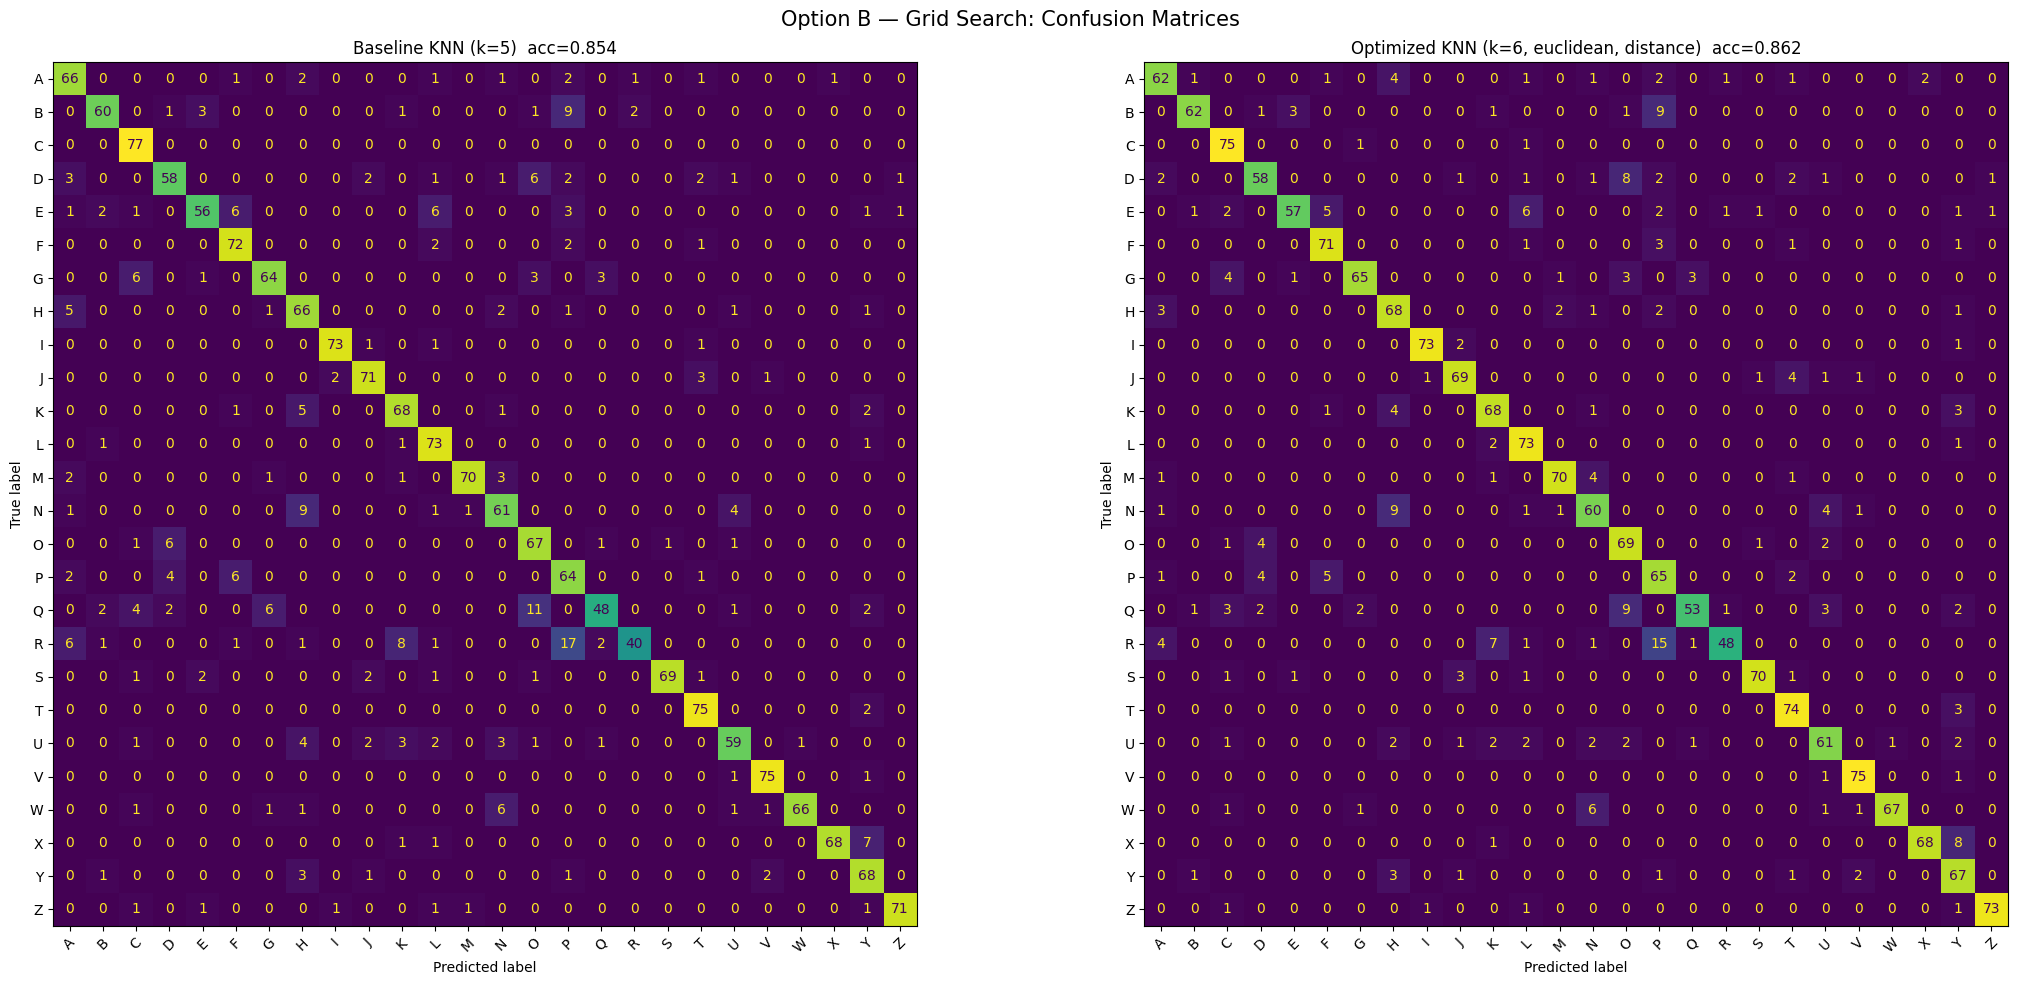

Confusion matrix saved to /content/drive/MyDrive/Models/KNN_OptionB/optionB_confusion_matrix.png


In [18]:
# ── 8. Confusion Matrix ───────────────────────────────────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionB"
os.makedirs(save_dir, exist_ok=True)
fig, axes = plt.subplots(1, 2, figsize=(22, 10))
labels = [chr(65+i) for i in range(26)]
for ax, y_p, title in zip(
    axes,
    [y_pred_base, y_pred_best],
    [f"Baseline KNN (k=5)  acc={acc_base:.3f}",
     f"Optimized KNN (k={best_params['k']}, {best_params['metric']}, "
     f"{best_params['weights']})  acc={acc_best:.3f}"]
):
    cm = confusion_matrix(y_test, y_p)
    disp = ConfusionMatrixDisplay(cm, display_labels=labels)
    disp.plot(ax=ax, colorbar=False, xticks_rotation=45)
    ax.set_title(title, fontsize=12)
plt.suptitle("Option B — Grid Search: Confusion Matrices", fontsize=15)
plt.tight_layout()
cm_path = os.path.join(save_dir, "optionB_confusion_matrix.png")
plt.savefig(cm_path, dpi=150)
plt.show()
print(f"Confusion matrix saved to {cm_path}")


Top configurations:
 k    metric  weights  cv_mean   cv_std
 6 euclidean distance 0.857018 0.006438
 5 euclidean distance 0.855389 0.006430
 4 euclidean distance 0.854514 0.003873
 3 euclidean distance 0.851759 0.004223
 8 euclidean distance 0.850381 0.004301
 7 euclidean distance 0.849004 0.005801
 1 euclidean  uniform 0.847504 0.006576
 1 euclidean distance 0.847504 0.006576
 2 euclidean distance 0.847504 0.006576
 5 euclidean  uniform 0.847376 0.006035


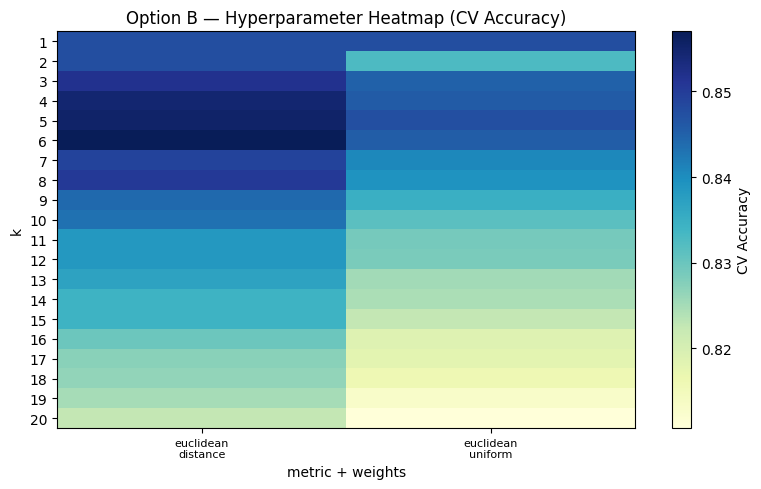

In [19]:
# ── 9.configurations heatmap ─────────────────────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionB"
os.makedirs(save_dir, exist_ok=True)
top = results_df.nlargest(10, 'cv_mean')[['k','metric','weights','cv_mean','cv_std']]
print("\nTop configurations:")
print(top.to_string(index=False))
fig, ax = plt.subplots(figsize=(8, 5))
pivot = results_df.pivot_table(index='k', columns=['metric','weights'],values='cv_mean')
im = ax.imshow(pivot.values, aspect='auto', cmap='YlGnBu')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f"{m}\n{w}" for m, w in pivot.columns], fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("metric + weights")
ax.set_ylabel("k")
plt.colorbar(im, ax=ax, label="CV Accuracy")
plt.title("Option B — Hyperparameter Heatmap (CV Accuracy)")
plt.tight_layout()
cm_path = os.path.join(save_dir, "configuration_heatmap.png")
plt.savefig(cm_path, dpi=150)
plt.show()

In [21]:
# ── 10. Summary ───────────────────────────────────────────────
import os
save_dir = "/content/drive/MyDrive/Models/KNN_OptionB"
os.makedirs(save_dir, exist_ok=True)
print("\n" + "="*55)
print("  OPTION B — RESULTS SUMMARY")
print("="*55)
print(f"Baseline  acc  : {acc_base:.4f} (k=5, euclidean, uniform)")
print(f"Optimized acc  : {acc_best:.4f}  "f"(k={best_params['k']},{best_params['metric']},{best_params['weights']})")
print(f"Improvement    : +{(acc_best - acc_base)*100:.2f}%")
print(f"Grid search time: {t_gs:.1f}s")
print("="*55)
# Save results for final comparison
results_B = {
    'option': 'B - Grid Search Hyperparameters',
    'accuracy': acc_best,
    'best_params': best_params,
    'report': classification_report(y_test, y_pred_best, output_dict=True,target_names=[chr(65+i) for i in range(26)])
}
save_path = os.path.join(save_dir, "results_B.npy")
np.save(save_path,results_B)
print(f"Results saved to {save_path}")


  OPTION B — RESULTS SUMMARY
Baseline  acc  : 0.8538 (k=5, euclidean, uniform)
Optimized acc  : 0.8618  (k=6,euclidean,distance)
Improvement    : +0.80%
Grid search time: 108.3s
Results saved to /content/drive/MyDrive/Models/KNN_OptionB/results_B.npy
